In [35]:
# Carregando as bibliotecas 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

In [36]:
# Carregando a base de dados
df = pd.read_csv("Maristela/plantas.csv")

print(f"Formato do dataset (linhas, colunas): {df.shape}\n")

# Informações gerais dos tipos de dados e contagem de não-nulos
print("--- Informações do Dataset ---")
df.info()

# Quantidade de valores nulos por coluna
print("\n--- Valores Ausentes (NaN) ---")
print(df.isnull().sum())

# Estatísticas descritivas (tamanhos negativos ou absurdos)
display(df.describe())

Formato do dataset (linhas, colunas): (3000, 6)

--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nome              3000 non-null   str    
 1   tamanho_cm        2845 non-null   float64
 2   necessidade_agua  3000 non-null   str    
 3   necessidade_luz   2851 non-null   str    
 4   toxica_para_pets  3000 non-null   int64  
 5   ideal_interno     3000 non-null   int64  
dtypes: float64(1), int64(2), str(3)
memory usage: 140.8 KB

--- Valores Ausentes (NaN) ---
nome                  0
tamanho_cm          155
necessidade_agua      0
necessidade_luz     149
toxica_para_pets      0
ideal_interno         0
dtype: int64


,tamanho_cm,toxica_para_pets,ideal_interno
count,2845.000000,3000.000000,3000.000000
mean,49.710721,0.299667,0.876000
std,19.769994,0.458188,0.329636
min,5.000000,0.000000,0.000000
25%,36.000000,0.000000,1.000000
50%,50.000000,0.000000,1.000000
75%,63.000000,1.000000,1.000000
max,115.000000,1.000000,1.000000


In [37]:
# Remove espaços em branco de todas as colunas de texto
colunas_texto = df.select_dtypes(include=['object', 'string']).columns
for col in colunas_texto:
    df[col] = df[col].str.strip()

# Tratando Linhas Duplicadas
print(f"Quantidade de linhas antes: {len(df)}")
df = df.drop_duplicates(keep='first')
print(f"Quantidade de linhas após remover duplicadas: {len(df)}")


Quantidade de linhas antes: 3000
Quantidade de linhas após remover duplicadas: 2544


In [38]:
print("Valores únicos em 'nome':", df['nome'].unique())
print("Valores únicos em 'necessidade_agua':", df['necessidade_agua'].unique())
print("Valores únicos em 'necessidade_luz':", df['necessidade_luz'].unique())
print("Valores únicos em 'toxica_para_pets':", df['toxica_para_pets'].unique())
print("Valores únicos em 'ideal_interno':", df['ideal_interno'].unique())


Valores únicos em 'nome': <StringArray>
['Ficus', 'Orquidea', 'Suculenta', 'Cacto', 'Espada-de-sao-jorge',
 'Samambaia']
Length: 6, dtype: str
Valores únicos em 'necessidade_agua': <StringArray>
['Media', 'Alta', 'Baixa']
Length: 3, dtype: str
Valores únicos em 'necessidade_luz': <StringArray>
[nan, 'Sol-pleno', 'Sombra', 'Meia-sombra']
Length: 4, dtype: str
Valores únicos em 'toxica_para_pets': [1 0]
Valores únicos em 'ideal_interno': [1 0]


In [39]:
# Separando as colunas
colunas_features = ['nome', 'tamanho_cm', 'necessidade_agua', 'necessidade_luz', 'toxica_para_pets']
X = df[colunas_features].copy()
y = df['ideal_interno'].copy()

# Separando em base de Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Formato do Treino:", X_train.shape)
print("Formato do Teste:", X_test.shape)


Formato do Treino: (1780, 5)
Formato do Teste: (764, 5)


In [40]:
from sklearn.impute import SimpleImputer

# Tratando as variáveis numéricas (tamanho_cm e toxica_para_pets)
colunas_num = ['tamanho_cm', 'toxica_para_pets']

imputer_num = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(
    imputer_num.fit_transform(X_train[colunas_num]),
    columns=colunas_num,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    imputer_num.transform(X_test[colunas_num]),
    columns=colunas_num,
    index=X_test.index
)

# Tratando as variáveis categóricas/texto
colunas_cat = ['nome', 'necessidade_agua', 'necessidade_luz']

imputer_cat = SimpleImputer(strategy="most_frequent")
X_train_cat = pd.DataFrame(
    imputer_cat.fit_transform(X_train[colunas_cat]),
    columns=colunas_cat,
    index=X_train.index
)
X_test_cat = pd.DataFrame(
    imputer_cat.transform(X_test[colunas_cat]),
    columns=colunas_cat,
    index=X_test.index
)



In [41]:
# Transformar as variáveis categóricas em numéricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Treina e aplica na base de treino
X_train_enc = pd.DataFrame(
    encoder.fit_transform(X_train_cat),
    columns=encoder.get_feature_names_out(colunas_cat),
    index=X_train_cat.index
)

# Aplica apenas na base de teste
X_test_enc = pd.DataFrame(
    encoder.transform(X_test_cat),
    columns=encoder.get_feature_names_out(colunas_cat),
    index=X_test_cat.index
)

# Juntando as tabelas numéricas tratadas com as novas colunas que acabamos de transformar
X_train_completo = pd.concat([X_train_num, X_train_enc], axis=1)
X_test_completo = pd.concat([X_test_num, X_test_enc], axis=1)


# Padronização de todas as variáveis para deixá-las na mesma escala
scaler = StandardScaler()

# Ajusta a escala e aplica nos dados de Treino
X_train_final = pd.DataFrame(
    scaler.fit_transform(X_train_completo),
    columns=X_train_completo.columns,
    index=X_train_completo.index
)

# Aplica a mesma escala nos dados de Teste
X_test_final = pd.DataFrame(
    scaler.transform(X_test_completo),
    columns=X_test_completo.columns,
    index=X_test_completo.index
)

display(X_train_final.head())


,tamanho_cm,toxica_para_pets,nome_Cacto,nome_Espada-de-sao-jorge,nome_Ficus,nome_Orquidea,nome_Samambaia,nome_Suculenta,necessidade_agua_Alta,necessidade_agua_Baixa,necessidade_agua_Media,necessidade_luz_Meia-sombra,necessidade_luz_Sol-pleno,necessidade_luz_Sombra
363,0.647841,-0.708597,-0.453830,2.221111,-0.465487,-0.435706,-0.439351,-0.438441,-0.687234,-0.711282,1.383205,-0.676625,1.479853,-0.770425
1065,0.697320,-0.708597,2.203466,-0.450225,-0.465487,-0.435706,-0.439351,-0.438441,-0.687234,-0.711282,1.383205,-0.676625,-0.675743,1.297985
2741,-1.974544,-0.708597,-0.453830,-0.450225,2.148288,-0.435706,-0.439351,-0.438441,-0.687234,-0.711282,1.383205,-0.676625,-0.675743,1.297985
1779,-1.133402,-0.708597,-0.453830,-0.450225,-0.465487,2.295126,-0.439351,-0.438441,1.455108,-0.711282,-0.722958,-0.676625,1.479853,-0.770425
516,-1.875586,-0.708597,-0.453830,2.221111,-0.465487,-0.435706,-0.439351,-0.438441,-0.687234,-0.711282,1.383205,-0.676625,-0.675743,1.297985


In [42]:
# Encontrando o melhor K (KNN)
k_values = range(1, 20)
melhor_k = 0
melhor_acc = 0

for k in k_values:
    # Criando o modelo KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Treinando o modelo
    knn.fit(X_train_final, y_train)

    # Pedindo para o modelo prever a base de teste
    y_pred = knn.predict(X_test_final)

    # Calculando a acurácia
    acc = accuracy_score(y_test, y_pred)

    print(f"k={k} vizinhos: Acurácia = {acc:.4f}")

    # Guardando a melhor
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print("-" * 30)
print(f"Acurácia final (Melhor k={melhor_k}): {melhor_acc:.4f}")


k=1 vizinhos: Acurácia = 0.7945
k=2 vizinhos: Acurácia = 0.7304
k=3 vizinhos: Acurácia = 0.8194
k=4 vizinhos: Acurácia = 0.7984
k=5 vizinhos: Acurácia = 0.8338
k=6 vizinhos: Acurácia = 0.8246
k=7 vizinhos: Acurácia = 0.8325
k=8 vizinhos: Acurácia = 0.8220
k=9 vizinhos: Acurácia = 0.8495
k=10 vizinhos: Acurácia = 0.8482
k=11 vizinhos: Acurácia = 0.8495
k=12 vizinhos: Acurácia = 0.8482
k=13 vizinhos: Acurácia = 0.8547
k=14 vizinhos: Acurácia = 0.8534
k=15 vizinhos: Acurácia = 0.8547
k=16 vizinhos: Acurácia = 0.8573
k=17 vizinhos: Acurácia = 0.8547
k=18 vizinhos: Acurácia = 0.8547
k=19 vizinhos: Acurácia = 0.8573
------------------------------
Acurácia final (Melhor k=16): 0.8573


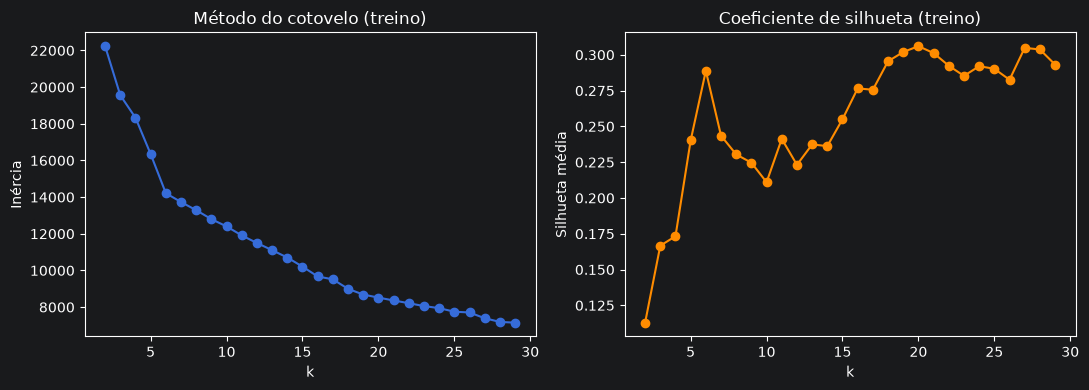

In [47]:
# Encontrando K pelo Kmeans
valores_k = range(2, 30)
inercias = []
silhuetas = []

for k in valores_k:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_k.fit_predict(X_train_final)
    inercias.append(modelo_k.inertia_)
    silhuetas.append(silhouette_score(X_train_final, labels_k))

# Gera os graficos de cotovelo e silhueta
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set_title("Método do cotovelo (treino)")
eixos[0].set_xlabel("k")
eixos[0].set_ylabel("Inércia")

eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set_title("Coeficiente de silhueta (treino)")
eixos[1].set_xlabel("k")
eixos[1].set_ylabel("Silhueta média")
plt.tight_layout()
plt.show()


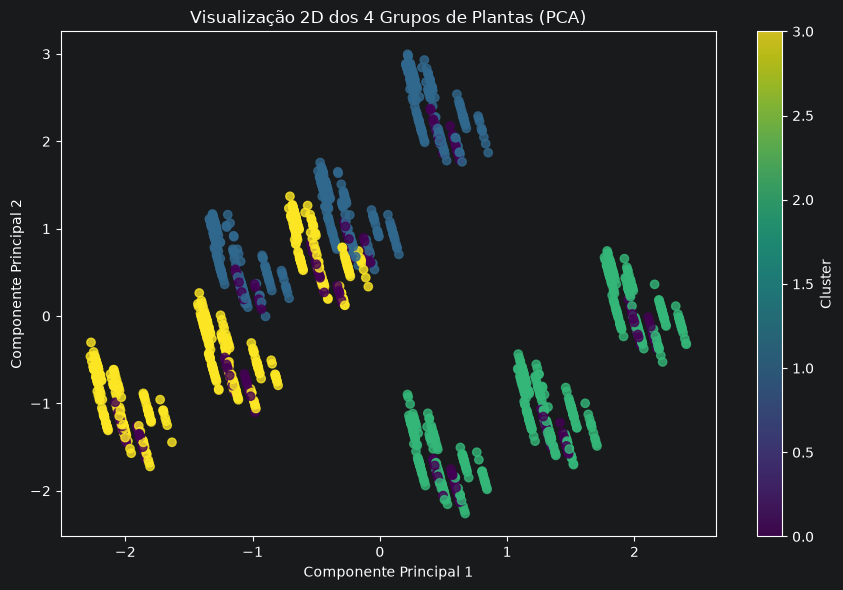

In [44]:
# Kmeans e grafico final
K_ESCOLHIDO = 4 

modelo_kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
labels_train = modelo_kmeans.fit_predict(X_train_final)

# Transformando os dados(PCA) para fazer o grafico
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_final)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_train, cmap="viridis", alpha=0.8)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title(f"Visualização 2D dos {K_ESCOLHIDO} Grupos de Plantas (PCA)")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()
